# Credit Default Risk Modeling Using Logistic Regression and XGBoost: A Risk-Based Lending Analysis

## 1. Introduction

Credit risk modeling is an important application of data analytics in the financial sector. 
The ability to identify borrowers who are more likely to default can help financial institutions 
make more informed lending decisions and manage potential credit losses.

In this project, loan data from Prosper is analyzed to develop machine learning models for 
predicting loan default risk. Logistic Regression and XGBoost are used as two different modeling 
approaches, and their predictive performances are compared using appropriate classification metrics.

The analysis also examines how predicted default probabilities can be used to support 
risk-based lending decisions.

### Research Question

**Can machine learning models accurately predict loan default risk, and how can these predictions 
support risk-based lending decisions?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\isken\OneDrive\Masaüstü\Credit Default Risk Modeling Using Logistic Regression and XGBoost A Risk-Based Lending Analysis\prosperLoanData.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("Number of columns:", df.shape[1])
print("Number of observations:", df.shape[0])

Dataset shape: (113937, 81)
Number of columns: 81
Number of observations: 113937


## 2. Data Understanding

The first step is to examine the structure and general characteristics of the dataset. 
This includes reviewing the variables, data types, and basic statistical information 
before starting the data preparation process.

In [2]:
print("First five rows:")
display(df.head())

First five rows:


,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
ListingKey                         str
ListingNumber                    int64
ListingCreationDate                str
CreditGrade                        str
Term                             int64
                                ...   
PercentFunded                  float64
Recommendations                  int64
InvestmentFromFriendsCount       int64
InvestmentFromFriendsAmount    float64
Investors                        int64
Length: 81, dtype: object


In [4]:

print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  str    
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  str    
 3   CreditGrade                          28953 non-null   str    
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  str    
 6   ClosedDate                           55089 non-null   str    
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  Est

In [5]:
loan_status_counts = df["LoanStatus"].value_counts()

print("Loan status distribution:")
print(loan_status_counts)

print("\nLoan status percentages:")
print((loan_status_counts / len(df) * 100).round(2))

Loan status distribution:
LoanStatus
Current                   56576
Completed                 38074
Chargedoff                11992
Defaulted                  5018
Past Due (1-15 days)        806
Past Due (31-60 days)       363
Past Due (61-90 days)       313
Past Due (91-120 days)      304
Past Due (16-30 days)       265
FinalPaymentInProgress      205
Past Due (>120 days)         16
Cancelled                     5
Name: count, dtype: int64

Loan status percentages:
LoanStatus
Current                   49.66
Completed                 33.42
Chargedoff                10.53
Defaulted                  4.40
Past Due (1-15 days)       0.71
Past Due (31-60 days)      0.32
Past Due (61-90 days)      0.27
Past Due (91-120 days)     0.27
Past Due (16-30 days)      0.23
FinalPaymentInProgress     0.18
Past Due (>120 days)       0.01
Cancelled                  0.00
Name: count, dtype: float64


In [6]:
df = df[df["LoanStatus"].isin(["Completed", "Chargedoff", "Defaulted"])].copy()

In [7]:
df["Default"] = df["LoanStatus"].isin(["Chargedoff", "Defaulted"]).astype(int)

print("Default distribution:")
print(df["Default"].value_counts())

print("\nDefault percentages:")
print((df["Default"].value_counts(normalize=True) * 100).round(2))

Default distribution:
Default
0    38074
1    17010
Name: count, dtype: int64

Default percentages:
Default
0    69.12
1    30.88
Name: proportion, dtype: float64


In [8]:
leakage_columns = [
    "LoanStatus",
    "ClosedDate",
    "LoanCurrentDaysDelinquent",
    "LoanFirstDefaultedCycleNumber",
    "LoanMonthsSinceOrigination",
    "LP_CustomerPayments",
    "LP_CustomerPrincipalPayments",
    "LP_InterestandFees",
    "LP_ServiceFees",
    "LP_CollectionFees",
    "LP_GrossPrincipalLoss",
    "LP_NetPrincipalLoss",
    "LP_NonPrincipalRecoverypayments",
    "PercentFunded",
    "InvestmentFromFriendsCount",
    "InvestmentFromFriendsAmount",
    "Investors"
]

In [9]:
id_columns = [
    "ListingKey",
    "ListingNumber",
    "LoanKey",
    "MemberKey",
    "GroupKey",
    "LoanNumber"
]

In [10]:
prosper_rating_columns = [
    "EstimatedReturn",
    "ProsperRating (numeric)",
    "EstimatedLoss",
    "EstimatedEffectiveYield",
    "ProsperScore",
    "ProsperRating (Alpha)"
]

df = df.drop(columns=prosper_rating_columns)

In [11]:
prosper_history_columns = [
    "TotalProsperLoans",
    "TotalProsperPaymentsBilled",
    "OnTimeProsperPayments",
    "ProsperPaymentsLessThanOneMonthLate",
    "ProsperPaymentsOneMonthPlusLate",
    "ProsperPrincipalBorrowed",
    "ProsperPrincipalOutstanding"
]

for column in prosper_history_columns:
    df[column] = df[column].fillna(0)

In [12]:
df = df.drop(
    columns=["ScorexChangeAtTimeOfListing", "CreditGrade"]
)

In [13]:
X = df.drop(columns=leakage_columns + id_columns + ["Default"])
y = df["Default"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (55084, 50)
Target: (55084,)


In [14]:
missing_values = (X.isnull().sum() / len(X) * 100).sort_values(ascending=False)

missing_values[missing_values > 0]

AmountDelinquent                      13.829787
EmploymentStatusDuration              13.817079
OpenCreditLines                       13.797110
RevolvingCreditBalance                13.797110
BankcardUtilization                   13.797110
CurrentCreditLines                    13.797110
PublicRecordsLast12Months             13.797110
TotalTrades                           13.688185
TradesOpenedLast6Months               13.688185
AvailableBankcardCredit               13.688185
TradesNeverDelinquent (percentage)    13.688185
BorrowerState                         10.006535
DebtToIncomeRatio                      7.679181
Occupation                             4.111902
EmploymentStatus                       4.088302
TotalInquiries                         2.096798
DelinquenciesLast7Years                1.791809
FirstRecordedCreditLine                1.263525
CurrentDelinquencies                   1.263525
PublicRecordsLast10Years               1.263525
InquiriesLast6Months                   1

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (44067, 50)
Test set: (11017, 50)


In [16]:
categorical_columns = X_train.select_dtypes(include="object").columns
numeric_columns = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", len(categorical_columns))
print("Numeric columns:", len(numeric_columns))

Categorical columns: 9
Numeric columns: 38


C:\Users\isken\AppData\Local\Temp\ipykernel_9592\1327556045.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X_train.select_dtypes(include="object").columns


In [17]:
for column in numeric_columns:
    median_value = X_train[column].median()
    
    X_train[column] = X_train[column].fillna(median_value)
    X_test[column] = X_test[column].fillna(median_value)


for column in categorical_columns:
    X_train[column] = X_train[column].fillna("Missing")
    X_test[column] = X_test[column].fillna("Missing")

In [18]:
print("Missing values in training set:", X_train.isnull().sum().sum())
print("Missing values in test set:", X_test.isnull().sum().sum())

Missing values in training set: 0
Missing values in test set: 0


In [19]:
date_columns = [
    "ListingCreationDate",
    "DateCreditPulled",
    "FirstRecordedCreditLine",
    "LoanOriginationDate",
    "LoanOriginationQuarter"
]

categorical_columns = [
    column for column in categorical_columns
    if column not in date_columns
]

print("Categorical columns:", len(categorical_columns))
print("Date columns:", len(date_columns))

Categorical columns: 4
Date columns: 5


In [20]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    drop_first=True
)

In [21]:
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (44067, 179)
Test set: (11017, 179)


In [22]:
X_train = X_train.drop(columns=date_columns)
X_test = X_test.drop(columns=date_columns)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [23]:
print("Non-numeric columns in training set:",
      X_train.select_dtypes(exclude=["number"]).shape[1])

print("Non-numeric columns in test set:",
      X_test.select_dtypes(exclude=["number"]).shape[1])

Non-numeric columns in training set: 0
Non-numeric columns in test set: 0


In [24]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

c:\Users\isken\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [25]:
logistic_probs = logistic_model.predict_proba(X_test)[:, 1]

In [26]:
from sklearn.metrics import roc_auc_score

logistic_auc = roc_auc_score(y_test, logistic_probs)

print("Logistic Regression ROC-AUC:", logistic_auc)

Logistic Regression ROC-AUC: 0.7162628062825043


In [27]:
from sklearn.metrics import classification_report

logistic_predictions = logistic_model.predict(X_test)

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Non-Default", "Default"]
    )
)

              precision    recall  f1-score   support

 Non-Default       0.73      0.93      0.82      7615
     Default       0.60      0.24      0.34      3402

    accuracy                           0.72     11017
   macro avg       0.67      0.58      0.58     11017
weighted avg       0.69      0.72      0.67     11017



In [28]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [29]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

In [30]:
xgb_auc = roc_auc_score(y_test, xgb_probs)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.771150124892738


In [31]:
xgb_predictions = xgb_model.predict(X_test)

print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=["Non-Default", "Default"]
    )
)

              precision    recall  f1-score   support

 Non-Default       0.76      0.92      0.83      7615
     Default       0.67      0.35      0.46      3402

    accuracy                           0.75     11017
   macro avg       0.71      0.64      0.65     11017
weighted avg       0.73      0.75      0.72     11017



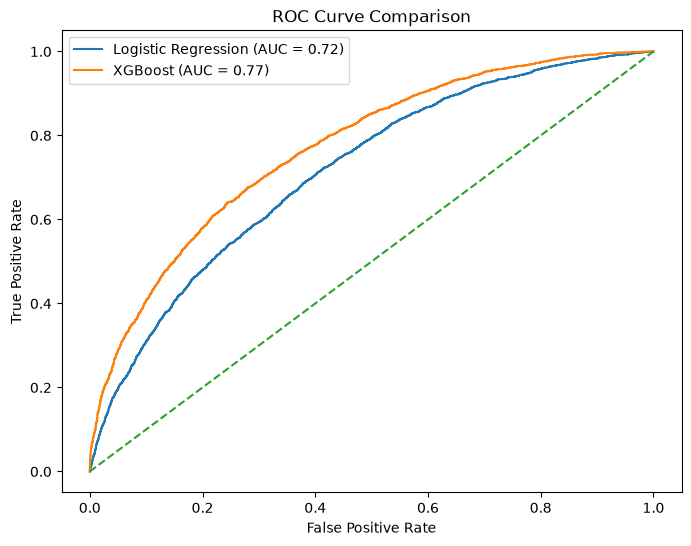

In [32]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

logistic_fpr, logistic_tpr, _ = roc_curve(y_test, logistic_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))

plt.plot(logistic_fpr, logistic_tpr, label=f"Logistic Regression (AUC = {logistic_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

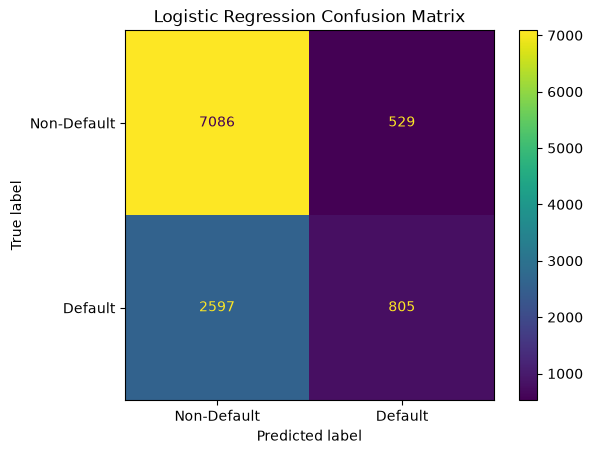

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

logistic_cm = confusion_matrix(y_test, logistic_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

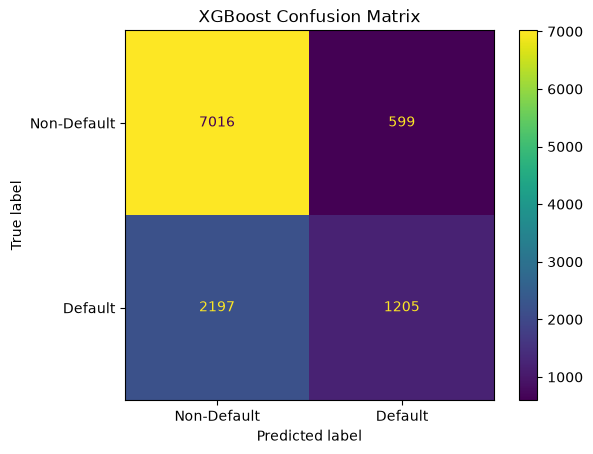

In [34]:
xgb_cm = confusion_matrix(y_test, xgb_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_ks = roc_curve(y_test, xgb_probs)

ks_values = tpr - fpr
ks = ks_values.max()

print("XGBoost KS:", ks)

XGBoost KS: 0.3963760454531593


In [36]:
from sklearn.calibration import CalibratedClassifierCV

xgb_calibrated = CalibratedClassifierCV(
    estimator=xgb_model,
    method="sigmoid",
    cv=5
)

xgb_calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary <n_jobs>` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
Name,Type,Value
"calibrated_classifiers_ calibrated_classifiers_: list (len() equal to cv or 1 if `ensemble=False`)The list of classifier and calibrator pairs.- When `ensemble=True`, `n_cv` fitted `estimator` and calibrator pairs. `n_cv` is the number of cross-validation folds.- When `ensemble=False`, the `estimator`, fitted on all the data, and fitted calibrator... versionchanged:: 0.24 Single calibrated classifier case when `ensemble=False`.",list,"[<sklearn.cali...001CBEB272F90>, <

In [37]:
xgb_calibrated_probs = xgb_calibrated.predict_proba(X_test)[:, 1]

print("First 10 calibrated default probabilities:")
print(xgb_calibrated_probs[:10])

First 10 calibrated default probabilities:
[0.17875955 0.36859565 0.10310744 0.39254028 0.29927138 0.17605555
 0.49057915 0.41580385 0.17502721 0.28302698]


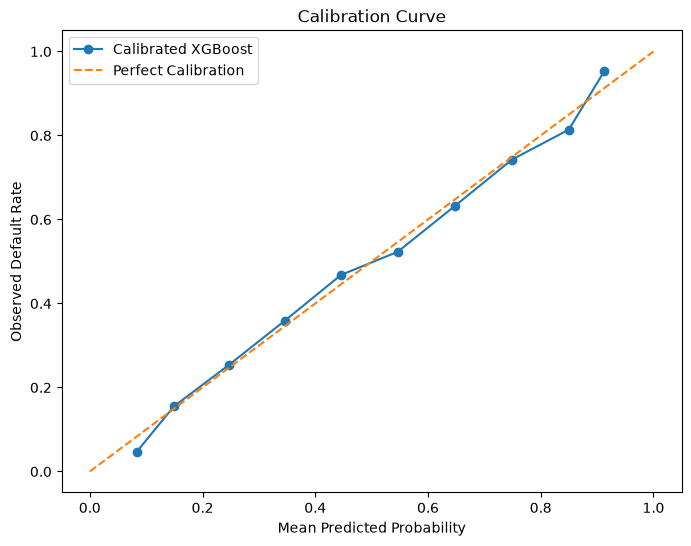

In [38]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    xgb_calibrated_probs,
    n_bins=10
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Calibrated XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

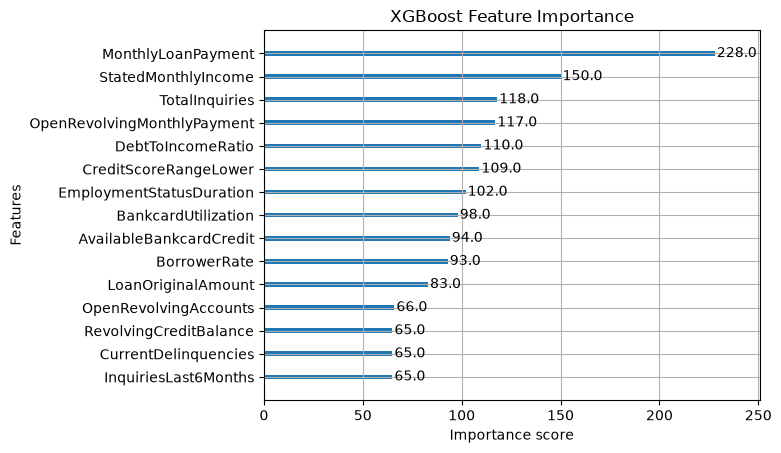

In [39]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=15)
plt.title("XGBoost Feature Importance")
plt.show()

In [40]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

c:\Users\isken\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


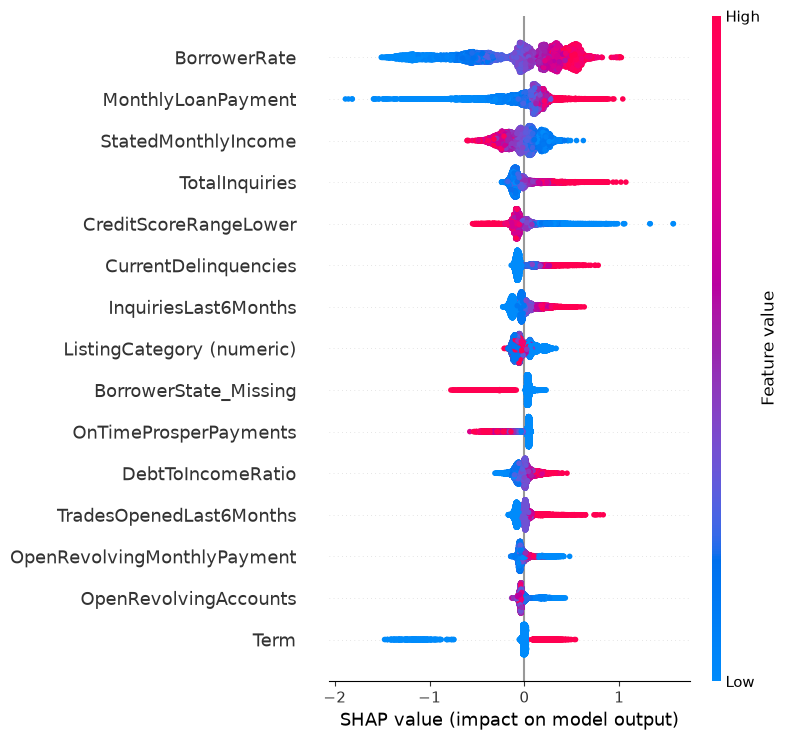

In [41]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)

In [42]:
risk_results = pd.DataFrame({
    "Actual_Default": y_test.values,
    "Default_Probability": xgb_calibrated_probs
})

risk_results.head()

,Actual_Default,Default_Probability
0,0,0.178760
1,1,0.368596
2,0,0.103107
3,1,0.392540
4,1,0.299271


In [43]:
risk_results["Default_Probability"].describe()

count    11017.000000
mean         0.309751
std          0.208569
min          0.065795
25%          0.146112
50%          0.249215
75%          0.421555
max          0.932214
Name: Default_Probability, dtype: float64

In [44]:
risk_results["Risk_Group"] = pd.qcut(
    risk_results["Default_Probability"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

risk_results["Risk_Group"].value_counts().sort_index()

Risk_Group
Low          2755
Medium       2754
High         2754
Very High    2754
Name: count, dtype: int64

In [45]:
risk_group_summary = (
    risk_results.groupby("Risk_Group", observed=True)
    .agg(
        Loan_Count=("Actual_Default", "count"),
        Actual_Default_Rate=("Actual_Default", "mean"),
        Average_PD=("Default_Probability", "mean")
    )
)

risk_group_summary["Actual_Default_Rate"] *= 100
risk_group_summary["Average_PD"] *= 100

risk_group_summary

,Loan_Count,Actual_Default_Rate,Average_PD
Risk_Group,,,
Low,2755,7.949183,10.334401
Medium,2754,21.314452,19.401503
High,2754,33.333333,32.649920
Very High,2754,60.929557,61.522107


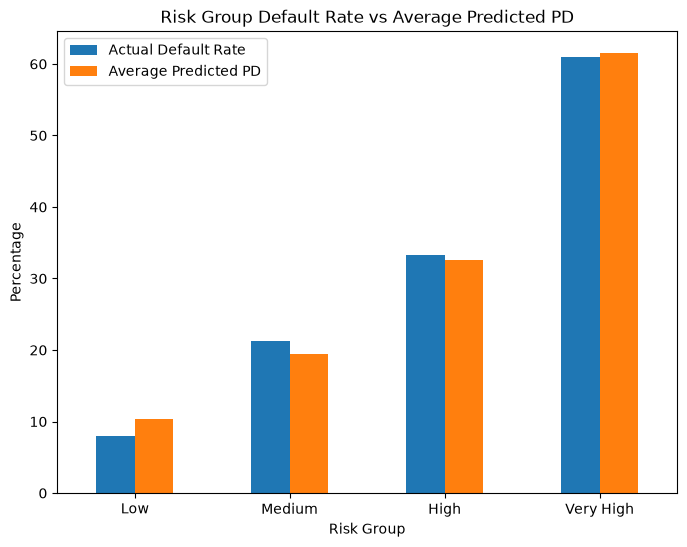

In [46]:
risk_group_summary[["Actual_Default_Rate", "Average_PD"]].plot(
    kind="bar",
    figsize=(8, 6)
)

plt.xlabel("Risk Group")
plt.ylabel("Percentage")
plt.title("Risk Group Default Rate vs Average Predicted PD")
plt.xticks(rotation=0)
plt.legend(["Actual Default Rate", "Average Predicted PD"])
plt.show()

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:
    predictions = (xgb_calibrated_probs >= threshold).astype(int)

    threshold_results.append([
        threshold,
        precision_score(y_test, predictions),
        recall_score(y_test, predictions),
        f1_score(y_test, predictions)
    ])

threshold_results = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Default Precision", "Default Recall", "Default F1"]
)

threshold_results

,Threshold,Default Precision,Default Recall,Default F1
0,0.10,0.345616,0.981481,0.511215
1,0.15,0.389182,0.932687,0.549199
2,0.20,0.430732,0.845385,0.570692
3,0.25,0.471798,0.762199,0.582828
4,0.30,0.514797,0.685185,0.587894
5,0.35,0.556793,0.602293,0.578650
6,0.40,0.593740,0.524103,0.556753
7,0.45,0.627581,0.446796,0.521978
8,0.50,0.657789,0.384774,0.485534


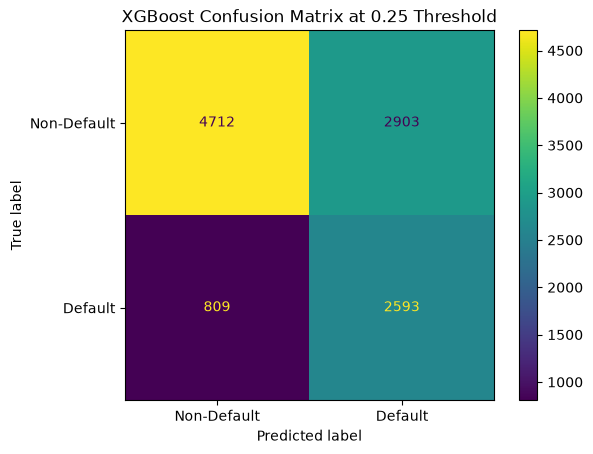

In [48]:
threshold = 0.25

threshold_predictions = (xgb_calibrated_probs >= threshold).astype(int)

threshold_cm = confusion_matrix(
    y_test,
    threshold_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=threshold_cm,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("XGBoost Confusion Matrix at 0.25 Threshold")
plt.show()

In [49]:
lgd = 0.80

risk_results["EAD"] = X_test["LoanOriginalAmount"].values
risk_results["Expected_Loss"] = (
    risk_results["Default_Probability"]
    * risk_results["EAD"]
    * lgd
)

risk_results[[
    "Default_Probability",
    "EAD",
    "Expected_Loss"
]].head()

,Default_Probability,EAD,Expected_Loss
0,0.178760,11500.0,1644.587846
1,0.368596,2000.0,589.753040
2,0.103107,5000.0,412.429765
3,0.392540,5000.0,1570.161111
4,0.299271,2500.0,598.542770


In [50]:
risk_loss_summary = (
    risk_results.groupby("Risk_Group", observed=True)
    .agg(
        Loan_Count=("Actual_Default", "count"),
        Average_PD=("Default_Probability", "mean"),
        Average_EAD=("EAD", "mean"),
        Total_Expected_Loss=("Expected_Loss", "sum"),
        Average_Expected_Loss=("Expected_Loss", "mean")
    )
)

risk_loss_summary["Average_PD"] *= 100

risk_loss_summary

,Loan_Count,Average_PD,Average_EAD,Total_Expected_Loss,Average_Expected_Loss
Risk_Group,,,,,
Low,2755,10.334401,5717.585844,1.326070e+06,481.332154
Medium,2754,19.401503,6563.508351,2.804106e+06,1018.193722
High,2754,32.649920,6369.619099,4.543827e+06,1649.900973
Very High,2754,61.522107,6299.761075,8.547451e+06,3103.649736


In [51]:
threshold_decision_results = []

for threshold in thresholds:
    approved = xgb_calibrated_probs < threshold

    approved_count = approved.sum()
    approval_rate = approved.mean() * 100

    total_expected_loss = risk_results.loc[
        approved, "Expected_Loss"
    ].sum()

    threshold_decision_results.append([
        threshold,
        approved_count,
        approval_rate,
        total_expected_loss
    ])

threshold_decision_results = pd.DataFrame(
    threshold_decision_results,
    columns=[
        "Threshold",
        "Approved Loans",
        "Approval Rate (%)",
        "Total Expected Loss"
    ]
)

threshold_decision_results

,Threshold,Approved Loans,Approval Rate (%),Total Expected Loss
0,0.10,1356,12.308251,4.677561e+05
1,0.15,2864,25.996188,1.414600e+06
2,0.20,4340,39.393664,2.756222e+06
3,0.25,5521,50.113461,4.145449e+06
4,0.30,6489,58.899882,5.606201e+06
5,0.35,7337,66.597077,6.961219e+06
6,0.40,8014,72.742126,8.199999e+06
7,0.45,8595,78.015794,9.328419e+06
8,0.50,9027,81.937006,1.041763e+07


In [52]:
final_threshold = 0.25

risk_results["Credit_Decision"] = np.where(
    risk_results["Default_Probability"] < final_threshold,
    "Approve",
    "Reject"
)

print("Final credit decision:")
print(risk_results["Credit_Decision"].value_counts())

Final credit decision:
Credit_Decision
Approve    5521
Reject     5496
Name: count, dtype: int64


In [53]:
final_strategy = (
    risk_results.groupby("Risk_Group", observed=True)
    .agg(
        Loan_Count=("Actual_Default", "count"),
        Average_PD=("Default_Probability", "mean"),
        Actual_Default_Rate=("Actual_Default", "mean"),
        Average_Expected_Loss=("Expected_Loss", "mean")
    )
)

final_strategy["Average_PD"] *= 100
final_strategy["Actual_Default_Rate"] *= 100

final_strategy["Recommended_Decision"] = [
    "Approve",
    "Approve with caution",
    "Restrict",
    "Reject"
]

final_strategy

,Loan_Count,Average_PD,Actual_Default_Rate,Average_Expected_Loss,Recommended_Decision
Risk_Group,,,,,
Low,2755,10.334401,7.949183,481.332154,Approve
Medium,2754,19.401503,21.314452,1018.193722,Approve with caution
High,2754,32.649920,33.333333,1649.900973,Restrict
Very High,2754,61.522107,60.929557,3103.649736,Reject


In [54]:
final_decision_summary = (
    risk_results.groupby("Credit_Decision", observed=True)
    .agg(
        Loan_Count=("Actual_Default", "count"),
        Actual_Default_Rate=("Actual_Default", "mean"),
        Average_PD=("Default_Probability", "mean"),
        Total_Expected_Loss=("Expected_Loss", "sum")
    )
)

final_decision_summary["Actual_Default_Rate"] *= 100
final_decision_summary["Average_PD"] *= 100

final_decision_summary

,Loan_Count,Actual_Default_Rate,Average_PD,Total_Expected_Loss
Credit_Decision,,,,
Approve,5521,14.653143,14.889066,4.145449e+06
Reject,5496,47.179767,47.134324,1.307601e+07


## Final Risk-Based Lending Strategy

The selected probability threshold of 0.25 is used to translate predicted default probabilities into lending decisions.

Loans with a predicted default probability below 0.25 are classified as "Approve", while loans with a probability of 0.25 or above are classified as "Reject".

This threshold reflects a trade-off between maintaining a reasonable approval rate and controlling expected credit losses.

## Conclusion

The analysis shows that machine learning can provide useful predictions of loan default risk using borrower and loan characteristics.

Logistic Regression achieved a ROC-AUC of 0.71, while XGBoost achieved a higher ROC-AUC of 0.77 and a KS statistic of 0.39. The XGBoost model also produced meaningful risk segmentation, with observed default rates increasing consistently from the Low-risk group to the Very High-risk group.

The predicted default probabilities were further translated into expected credit losses using Probability of Default (PD), Exposure at Default (EAD), and an assumed Loss Given Default (LGD) of 80%.

A probability threshold of 0.25 was selected as the final lending decision threshold by considering the trade-off between model performance, approval rate, and expected credit loss. Under this threshold, loans with predicted default probabilities below 0.25 are approved, while loans with probabilities of 0.25 or higher are rejected.

Overall, the results demonstrate that machine learning-based default probabilities can support risk-based lending decisions by helping lenders differentiate risk levels and incorporate expected credit losses into the decision process.